# Model Training for Sentiment Analysis

## 1. TripAdvisor Clean Dataset: TF-IDF + Model + Simulation

In [15]:
import pandas as pd
import numpy as np
import os
import re
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [16]:
# Load cleaned TripAdvisor dataset
tripadvisor_path = '../data/processed/tripadvisor_cleaned.csv'
df_tripadvisor = pd.read_csv(tripadvisor_path)

print('Dataset shape:', df_tripadvisor.shape)
print('Columns:', df_tripadvisor.columns.tolist())
print('\nHead:')
display(df_tripadvisor.head())
print('\nMissing values:')
print(df_tripadvisor.isnull().sum())

Dataset shape: (20491, 5)
Columns: ['Review', 'Rating', 'clean_review', 'sentiment', 'token_count']

Head:


,Review,Rating,clean_review,sentiment,token_count
0,nice hotel expensive parking got good deal sta...,4,nice hotel expensive parking got good deal sta...,positive,86
1,ok nothing special charge diamond member hilto...,2,ok nothing special charge diamond member hilto...,negative,243
2,nice rooms not 4* experience hotel monaco seat...,3,nice rooms not experience hotel monaco seattle...,neutral,208
3,"unique, great stay, wonderful time hotel monac...",5,unique great stay wonderful time hotel monaco ...,positive,88
4,"great stay great stay, went seahawk game aweso...",5,great stay great stay went seahawk game awesom...,positive,189



Missing values:
Review          0
Rating          0
clean_review    0
sentiment       0
token_count     0
dtype: int64


In [17]:
X = df_tripadvisor['clean_review'].fillna('')
y = df_tripadvisor['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Training set size:', len(X_train))
print('Test set size:', len(X_test))

Training set size: 16392
Test set size: 4099


In [18]:
tfidf_tripadvisor = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9
)

X_train_tfidf = tfidf_tripadvisor.fit_transform(X_train)
X_test_tfidf = tfidf_tripadvisor.transform(X_test)

print('TF-IDF feature matrix shape (train):', X_train_tfidf.shape)
print('TF-IDF feature matrix shape (test):', X_test_tfidf.shape)

TF-IDF feature matrix shape (train): (16392, 10000)
TF-IDF feature matrix shape (test): (4099, 10000)


In [19]:
model_tripadvisor = LogisticRegression(max_iter=1000, class_weight='balanced')
model_tripadvisor.fit(X_train_tfidf, y_train)

y_pred = model_tripadvisor.predict(X_test_tfidf)

print('Classification Report:')
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

    negative       0.76      0.81      0.78       643
     neutral       0.35      0.50      0.41       437
    positive       0.95      0.88      0.91      3019

    accuracy                           0.83      4099
   macro avg       0.68      0.73      0.70      4099
weighted avg       0.86      0.83      0.84      4099



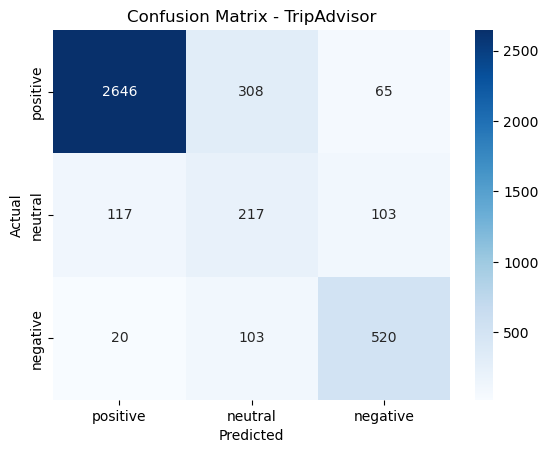

In [20]:
cm = confusion_matrix(y_test, y_pred, labels=['positive', 'neutral', 'negative'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['positive', 'neutral', 'negative'], yticklabels=['positive', 'neutral', 'negative'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - TripAdvisor')
plt.show()

In [21]:
os.makedirs('../models', exist_ok=True)
joblib.dump(model_tripadvisor, '../models/tripadvisor_sentiment_model.pkl')
joblib.dump(tfidf_tripadvisor, '../models/tripadvisor_tfidf_vectorizer.pkl')
print('Saved TripAdvisor model and vectorizer.')

Saved TripAdvisor model and vectorizer.


In [22]:
def simulate_tripadvisor_review(review):
    loaded_model = joblib.load('../models/tripadvisor_sentiment_model.pkl')
    loaded_tfidf = joblib.load('../models/tripadvisor_tfidf_vectorizer.pkl')

    review_clean = re.sub(r'[^a-zA-Z\s]', ' ', str(review).lower())
    review_clean = re.sub(r'\s+', ' ', review_clean).strip()

    review_tfidf = loaded_tfidf.transform([review_clean])
    sentiment = loaded_model.predict(review_tfidf)[0]
    confidence = None
    if hasattr(loaded_model, 'predict_proba'):
        confidence = loaded_model.predict_proba(review_tfidf).max()
    return {
        'review': review,
        'sentiment': sentiment,
        'confidence': confidence
    }

for test_review in [
    'The room was clean but the staff were rude.',
    'The hotel was okay but nothing special.',
    'The bathroom was dirty and the food was terrible.'
]:
    result = simulate_tripadvisor_review(test_review)
    print(result)

{'review': 'The room was clean but the staff were rude.', 'sentiment': 'negative', 'confidence': np.float64(0.46826445491582547)}
{'review': 'The hotel was okay but nothing special.', 'sentiment': 'neutral', 'confidence': np.float64(0.9471940119045803)}
{'review': 'The bathroom was dirty and the food was terrible.', 'sentiment': 'negative', 'confidence': np.float64(0.9401554721142403)}


## 2. TA13 Clean Dataset: TF-IDF + Model + Aspect-Aware Backend Demo

In [23]:
# Load cleaned TA13 dataset
ta13_path = '../data/processed/ta13_cleaned.csv'
df_ta13 = pd.read_csv(ta13_path)

print('Dataset shape:', df_ta13.shape)
print('Columns:', df_ta13.columns.tolist())
print('\nHead:')
display(df_ta13.head())
print('\nMissing values:')
print(df_ta13.isnull().sum())

Dataset shape: (79756, 19)
Columns: ['offering_id', 'user_id', 'overall', 'value', 'service', 'location', 'rooms', 'cleanliness', 'sleep_quality', 'review_text', 'clean_review', 'sentiment', 'value_sentiment', 'service_sentiment', 'location_sentiment', 'rooms_sentiment', 'cleanliness_sentiment', 'sleep_quality_sentiment', 'token_count']

Head:


,offering_id,user_id,overall,value,service,location,rooms,cleanliness,sleep_quality,review_text,clean_review,sentiment,value_sentiment,service_sentiment,location_sentiment,rooms_sentiment,cleanliness_sentiment,sleep_quality_sentiment,token_count
0,1762573,FB1032DECE1162CB3556D05F278AAFFD,4.0,4.0,4.0,5.0,4.0,5.0,4.0,“Great Stay” This is a great property in Midto...,great stay this is a great property in midtown...,positive,positive,positive,positive,positive,positive,positive,95
1,1762573,BA524A238B1171206691A6CC3F28F266,4.0,3.0,4.0,5.0,5.0,5.0,5.0,“Its the best of the Andaz Brand in the US.......,its the best of the andaz brand in the us i ha...,positive,neutral,positive,positive,positive,positive,positive,462
2,1456560,EC6CB11E9DC8761710DDA3CF48DD995F,4.0,4.0,4.0,5.0,4.0,5.0,5.0,“A Nice Stay for NYC!” This hotel is a nice st...,a nice stay for nyc this hotel is a nice stay ...,positive,positive,positive,positive,positive,positive,positive,91
3,1762573,C81AB7D49D98FA410EA191E15F427BEC,4.0,5.0,4.0,5.0,5.0,5.0,5.0,“Stunningly Wonderful!” Other hotels in NYC th...,stunningly wonderful other hotels in nyc that ...,positive,positive,positive,positive,positive,positive,positive,172
4,1456560,2404E3630B78BB9E8D6583076FBA0742,4.0,4.0,4.0,4.0,4.0,4.0,5.0,"“Modern, minimalist, central hotel” We got a r...",modern minimalist central hotel we got a reaso...,positive,positive,positive,positive,positive,positive,positive,140



Missing values:
offering_id                    0
user_id                        0
overall                        0
value                       7227
service                     7594
location                   15544
rooms                      12366
cleanliness                 7107
sleep_quality              34382
review_text                    0
clean_review                   0
sentiment                      0
value_sentiment                0
service_sentiment              0
location_sentiment             0
rooms_sentiment                0
cleanliness_sentiment          0
sleep_quality_sentiment        0
token_count                    0
dtype: int64


In [24]:
X = df_ta13['clean_review'].fillna('')
y = df_ta13['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Training set size:', len(X_train))
print('Test set size:', len(X_test))

Training set size: 63804
Test set size: 15952


In [25]:
tfidf_ta13 = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9
)

X_train_tfidf = tfidf_ta13.fit_transform(X_train)
X_test_tfidf = tfidf_ta13.transform(X_test)

print('TF-IDF feature matrix shape (train):', X_train_tfidf.shape)
print('TF-IDF feature matrix shape (test):', X_test_tfidf.shape)

TF-IDF feature matrix shape (train): (63804, 10000)
TF-IDF feature matrix shape (test): (15952, 10000)


In [26]:
model_ta13 = LogisticRegression(max_iter=1000, class_weight='balanced')
model_ta13.fit(X_train_tfidf, y_train)

y_pred = model_ta13.predict(X_test_tfidf)

print('Classification Report:')
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

    negative       0.55      0.72      0.62      1411
     neutral       0.51      0.62      0.56      3149
    positive       0.94      0.85      0.89     11392

    accuracy                           0.79     15952
   macro avg       0.67      0.73      0.69     15952
weighted avg       0.82      0.79      0.80     15952



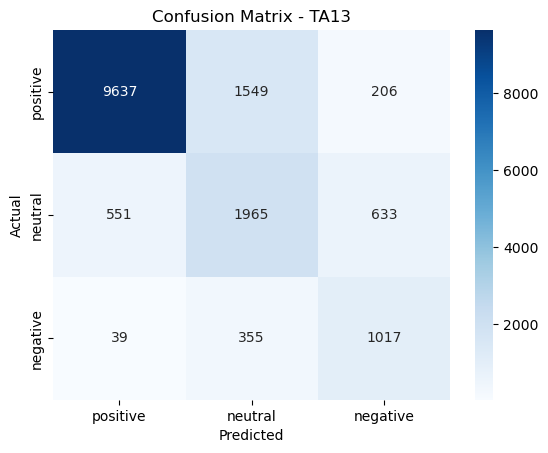

In [27]:
cm = confusion_matrix(y_test, y_pred, labels=['positive', 'neutral', 'negative'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['positive', 'neutral', 'negative'], yticklabels=['positive', 'neutral', 'negative'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - TA13')
plt.show()

In [28]:
os.makedirs('../models', exist_ok=True)
joblib.dump(model_ta13, '../models/ta13_sentiment_model.pkl')
joblib.dump(tfidf_ta13, '../models/ta13_tfidf_vectorizer.pkl')
print('Saved TA13 model and vectorizer.')

Saved TA13 model and vectorizer.


In [34]:
aspect_keywords = {
    'cleanliness': ['clean', 'dirty', 'bathroom', 'toilet', 'smell', 'dust', 'hygiene'],
    'staff_service': ['staff', 'service', 'reception', 'manager', 'rude', 'friendly', 'helpful'],
    'food': ['food', 'breakfast', 'restaurant', 'meal', 'buffet', 'coffee'],
    'room': ['room', 'bed', 'shower', 'aircon', 'noise', 'view'],
    'location': ['location', 'station', 'walk', 'near', 'transport', 'city'],
    'value': ['price', 'value', 'expensive', 'cheap', 'worth', 'money']
}
positive_words = ['good', 'great', 'excellent', 'amazing', 'clean', 'friendly', 'helpful', 'comfortable', 'nice', 'perfect', 'love', 'best']
negative_words = ['bad', 'dirty', 'rude', 'terrible', 'poor', 'noisy', 'slow', 'broken', 'smelly', 'awful', 'worst', 'disappointing']

clause_split_pattern = re.compile(r',|\.|\bbut\b|\band\b|\bhowever\b|\balthough\b', flags=re.IGNORECASE)

def detect_aspect_sentiment(review):
    review_lower = str(review).lower()
    clauses = [clause.strip() for clause in clause_split_pattern.split(review_lower) if clause.strip()]
    aspect_sentiments = {}

    for aspect, keywords in aspect_keywords.items():
        sentiment_votes = []
        for clause in clauses:
            if any(keyword in clause for keyword in keywords):
                pos_count = sum(1 for word in positive_words if word in clause)
                neg_count = sum(1 for word in negative_words if word in clause)
                if neg_count > pos_count:
                    sentiment_votes.append('negative')
                elif pos_count > neg_count:
                    sentiment_votes.append('positive')
                else:
                    sentiment_votes.append('not mentioned')
        if sentiment_votes:
            if 'negative' in sentiment_votes:
                aspect_sentiments[aspect] = 'negative'
            elif 'positive' in sentiment_votes:
                aspect_sentiments[aspect] = 'positive'
            else:
                aspect_sentiments[aspect] = 'not mentioned'
        else:
            aspect_sentiments[aspect] = 'not mentioned'
    return aspect_sentiments


def predict_ta13_review_analysis(review):
    loaded_model = joblib.load('../models/ta13_sentiment_model.pkl')
    loaded_tfidf = joblib.load('../models/ta13_tfidf_vectorizer.pkl')

    review_clean = re.sub(r'[^a-zA-Z\s]', ' ', str(review).lower())
    review_clean = re.sub(r'\s+', ' ', review_clean).strip()

    review_tfidf = loaded_tfidf.transform([review_clean])
    overall_sentiment = loaded_model.predict(review_tfidf)[0]
    confidence = None
    if hasattr(loaded_model, 'predict_proba'):
        confidence = loaded_model.predict_proba(review_tfidf).max()

    aspects = detect_aspect_sentiment(review)
    return {
        'review': review,
        'overall_sentiment': overall_sentiment,
        'confidence': confidence,
        'aspects': aspects
    }

result = predict_ta13_review_analysis('The bathroom was dirty and the staff were rude, but the food was good')
print(result)

{'review': 'The bathroom was dirty and the staff were rude, but the food was good', 'overall_sentiment': 'negative', 'confidence': np.float64(0.7965191643992292), 'aspects': {'cleanliness': 'negative', 'staff_service': 'negative', 'food': 'positive', 'room': 'negative', 'location': 'not mentioned', 'value': 'not mentioned'}}


## Summary

- The TripAdvisor model is a baseline sentiment model trained on the cleaned TripAdvisor hotel review dataset.
- The TA13 model is a stronger backend candidate because it is trained on a dataset with overall ratings and aspect ratings.
- A rule-based aspect layer is included for prototype explainability and aspect-aware demo output.

# TA13 Aspect Sentiment Models

In [35]:
df = pd.read_csv("../data/processed/ta13_cleaned.csv")

df.head()

,offering_id,user_id,overall,value,service,location,rooms,cleanliness,sleep_quality,review_text,clean_review,sentiment,value_sentiment,service_sentiment,location_sentiment,rooms_sentiment,cleanliness_sentiment,sleep_quality_sentiment,token_count
0,1762573,FB1032DECE1162CB3556D05F278AAFFD,4.0,4.0,4.0,5.0,4.0,5.0,4.0,“Great Stay” This is a great property in Midto...,great stay this is a great property in midtown...,positive,positive,positive,positive,positive,positive,positive,95
1,1762573,BA524A238B1171206691A6CC3F28F266,4.0,3.0,4.0,5.0,5.0,5.0,5.0,“Its the best of the Andaz Brand in the US.......,its the best of the andaz brand in the us i ha...,positive,neutral,positive,positive,positive,positive,positive,462
2,1456560,EC6CB11E9DC8761710DDA3CF48DD995F,4.0,4.0,4.0,5.0,4.0,5.0,5.0,“A Nice Stay for NYC!” This hotel is a nice st...,a nice stay for nyc this hotel is a nice stay ...,positive,positive,positive,positive,positive,positive,positive,91
3,1762573,C81AB7D49D98FA410EA191E15F427BEC,4.0,5.0,4.0,5.0,5.0,5.0,5.0,“Stunningly Wonderful!” Other hotels in NYC th...,stunningly wonderful other hotels in nyc that ...,positive,positive,positive,positive,positive,positive,positive,172
4,1456560,2404E3630B78BB9E8D6583076FBA0742,4.0,4.0,4.0,4.0,4.0,4.0,5.0,"“Modern, minimalist, central hotel” We got a r...",modern minimalist central hotel we got a reaso...,positive,positive,positive,positive,positive,positive,positive,140


In [36]:
def rating_to_sentiment(score):
    if pd.isna(score):
        return np.nan
    elif score >= 4:
        return "positive"
    elif score == 3:
        return "neutral"
    else:
        return "negative"

In [37]:
aspect_cols = [
    "value",
    "service",
    "location",
    "rooms",
    "cleanliness",
    "sleep_quality"
]

os.makedirs("../models/aspect_models", exist_ok=True)

aspect_results = {}

for aspect in aspect_cols:
    print("=" * 80)
    print(f"Training aspect model for: {aspect}")
    print("=" * 80)
    
    # Create temporary dataset for this aspect
    aspect_df = df[["clean_review", aspect]].copy()
    
    # Remove rows where this aspect rating is missing
    aspect_df = aspect_df.dropna(subset=[aspect])
    
    # Create aspect sentiment label
    aspect_df["aspect_sentiment"] = aspect_df[aspect].apply(rating_to_sentiment)
    
    # Remove any empty text
    aspect_df = aspect_df.dropna(subset=["clean_review", "aspect_sentiment"])
    aspect_df = aspect_df[aspect_df["clean_review"].str.strip() != ""]
    
    print("Dataset shape:", aspect_df.shape)
    print("Class distribution:")
    print(aspect_df["aspect_sentiment"].value_counts())
    
    X = aspect_df["clean_review"]
    y = aspect_df["aspect_sentiment"]
    
    # Skip if one class is too small
    if y.nunique() < 2:
        print(f"Skipping {aspect}: not enough sentiment classes.")
        continue
    
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )
    
    tfidf = TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.9
    )
    
    X_train_tfidf = tfidf.fit_transform(X_train)
    X_test_tfidf = tfidf.transform(X_test)
    
    model = LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    )
    
    model.fit(X_train_tfidf, y_train)
    
    y_pred = model.predict(X_test_tfidf)
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Save model and vectorizer
    model_path = f"../models/aspect_models/{aspect}_sentiment_model.pkl"
    tfidf_path = f"../models/aspect_models/{aspect}_tfidf_vectorizer.pkl"
    
    joblib.dump(model, model_path)
    joblib.dump(tfidf, tfidf_path)
    
    aspect_results[aspect] = {
        "rows_used": len(aspect_df),
        "model_path": model_path,
        "tfidf_path": tfidf_path
    }

aspect_results

Training aspect model for: value
Dataset shape: (72529, 3)
Class distribution:
aspect_sentiment
positive    48035
neutral     16851
negative     7643
Name: count, dtype: int64

Classification Report:
              precision    recall  f1-score   support

    negative       0.47      0.71      0.57      1529
     neutral       0.40      0.48      0.43      3370
    positive       0.87      0.74      0.80      9607

    accuracy                           0.67     14506
   macro avg       0.58      0.64      0.60     14506
weighted avg       0.72      0.67      0.69     14506

Training aspect model for: service
Dataset shape: (72162, 3)
Class distribution:
aspect_sentiment
positive    53552
neutral     12338
negative     6272
Name: count, dtype: int64

Classification Report:
              precision    recall  f1-score   support

    negative       0.44      0.65      0.53      1254
     neutral       0.36      0.53      0.43      2468
    positive       0.92      0.77      0.84     10711


{'value': {'rows_used': 72529,
  'model_path': '../models/aspect_models/value_sentiment_model.pkl',
  'tfidf_path': '../models/aspect_models/value_tfidf_vectorizer.pkl'},
 'service': {'rows_used': 72162,
  'model_path': '../models/aspect_models/service_sentiment_model.pkl',
  'tfidf_path': '../models/aspect_models/service_tfidf_vectorizer.pkl'},
 'location': {'rows_used': 64212,
  'model_path': '../models/aspect_models/location_sentiment_model.pkl',
  'tfidf_path': '../models/aspect_models/location_tfidf_vectorizer.pkl'},
 'rooms': {'rows_used': 67390,
  'model_path': '../models/aspect_models/rooms_sentiment_model.pkl',
  'tfidf_path': '../models/aspect_models/rooms_tfidf_vectorizer.pkl'},
 'cleanliness': {'rows_used': 72649,
  'model_path': '../models/aspect_models/cleanliness_sentiment_model.pkl',
  'tfidf_path': '../models/aspect_models/cleanliness_tfidf_vectorizer.pkl'},
 'sleep_quality': {'rows_used': 45374,
  'model_path': '../models/aspect_models/sleep_quality_sentiment_model.pk

In [38]:
import os
import re
import joblib

aspect_cols = [
    "value",
    "service",
    "location",
    "rooms",
    "cleanliness",
    "sleep_quality"
]

aspect_detection_keywords = {
    "value": [
        "price", "value", "expensive", "cheap", "worth", "money",
        "cost", "overpriced", "reasonable", "affordable"
    ],
    "service": [
        "staff", "service", "reception", "receptionist", "front desk",
        "manager", "concierge", "rude", "friendly", "helpful", "unhelpful"
    ],
    "location": [
        "location", "station", "walk", "near", "transport", "city",
        "airport", "beach", "shopping", "subway", "bus", "train"
    ],
    "rooms": [
        "room", "bed", "pillow", "shower", "aircon", "air conditioning",
        "noise", "view", "wifi", "tv", "furniture", "bathroom"
    ],
    "cleanliness": [
        "clean", "dirty", "bathroom", "toilet", "smell", "dust",
        "hygiene", "mold", "stain", "filthy", "spotless"
    ],
    "sleep_quality": [
        "sleep", "quiet", "noisy", "noise", "bed", "pillow",
        "mattress", "comfortable", "uncomfortable"
    ]
}

def clean_review_text(review):
    review_clean = re.sub(r"[^a-zA-Z\s]", " ", str(review).lower())
    review_clean = re.sub(r"\s+", " ", review_clean).strip()
    return review_clean


def detect_mentioned_aspects(review):
    review_lower = str(review).lower()
    mentioned_aspects = []

    for aspect, keywords in aspect_detection_keywords.items():
        if any(keyword in review_lower for keyword in keywords):
            mentioned_aspects.append(aspect)

    return mentioned_aspects


def predict_aspect_models_hybrid(review):
    aspect_predictions = {}

    review_clean = clean_review_text(review)
    mentioned_aspects = detect_mentioned_aspects(review)

    for aspect in aspect_cols:

        # If aspect is not mentioned, do not run model
        if aspect not in mentioned_aspects:
            aspect_predictions[aspect] = {
                "sentiment": "not mentioned",
                "confidence": None
            }
            continue

        model_path = f"../models/aspect_models/{aspect}_sentiment_model.pkl"
        tfidf_path = f"../models/aspect_models/{aspect}_tfidf_vectorizer.pkl"

        if not os.path.exists(model_path) or not os.path.exists(tfidf_path):
            aspect_predictions[aspect] = {
                "sentiment": "model not available",
                "confidence": None
            }
            continue

        model = joblib.load(model_path)
        tfidf = joblib.load(tfidf_path)

        review_tfidf = tfidf.transform([review_clean])
        prediction = model.predict(review_tfidf)[0]

        confidence = None
        if hasattr(model, "predict_proba"):
            confidence = float(model.predict_proba(review_tfidf).max())

        aspect_predictions[aspect] = {
            "sentiment": prediction,
            "confidence": confidence
        }

    return aspect_predictions

In [39]:
review = "The bathroom was dirty and the staff were rude, but the location was good."

predict_aspect_models_hybrid(review)

{'value': {'sentiment': 'not mentioned', 'confidence': None},
 'service': {'sentiment': 'negative', 'confidence': 0.927994021506076},
 'location': {'sentiment': 'negative', 'confidence': 0.8289620360765801},
 'rooms': {'sentiment': 'neutral', 'confidence': 0.5582537955027844},
 'cleanliness': {'sentiment': 'negative', 'confidence': 0.9930632435567343},
 'sleep_quality': {'sentiment': 'not mentioned', 'confidence': None}}

# Model with datasets swapped

In [31]:
import pandas as pd
import joblib
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

trip_df = pd.read_csv("../data/processed/tripadvisor_cleaned.csv")
ta13_df = pd.read_csv("../data/processed/ta13_cleaned.csv")

trip_model = joblib.load("../models/tripadvisor_sentiment_model.pkl")
trip_tfidf = joblib.load("../models/tripadvisor_tfidf_vectorizer.pkl")

ta13_model = joblib.load("../models/ta13_sentiment_model.pkl")
ta13_tfidf = joblib.load("../models/ta13_tfidf_vectorizer.pkl")

Test TripAdvisor model on TA13 dataset

TripAdvisor model tested on TA13 dataset
              precision    recall  f1-score   support

    negative       0.42      0.75      0.54      7055
     neutral       0.33      0.64      0.43     15743
    positive       0.95      0.61      0.75     56958

    accuracy                           0.63     79756
   macro avg       0.57      0.67      0.57     79756
weighted avg       0.78      0.63      0.67     79756



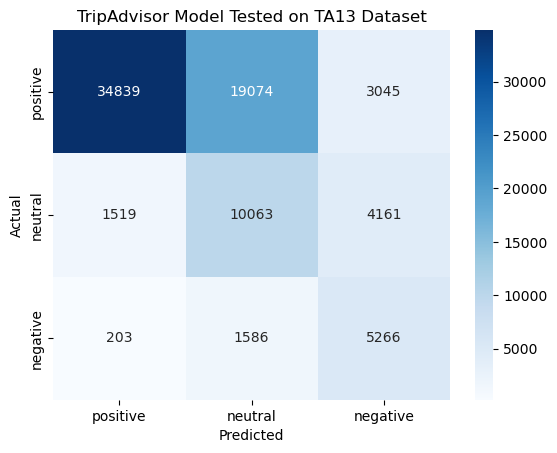

In [32]:
X_ta13 = ta13_df["clean_review"]
y_ta13 = ta13_df["sentiment"]

X_ta13_trip_tfidf = trip_tfidf.transform(X_ta13)
y_pred_trip_on_ta13 = trip_model.predict(X_ta13_trip_tfidf)

print("TripAdvisor model tested on TA13 dataset")
print(classification_report(y_ta13, y_pred_trip_on_ta13))

cm = confusion_matrix(
    y_ta13,
    y_pred_trip_on_ta13,
    labels=["positive", "neutral", "negative"]
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["positive", "neutral", "negative"],
    yticklabels=["positive", "neutral", "negative"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("TripAdvisor Model Tested on TA13 Dataset")
plt.show()

Test TA13 model on TripAdvisor dataset

TA13 model tested on TripAdvisor dataset
              precision    recall  f1-score   support

    negative       0.83      0.67      0.74      3214
     neutral       0.38      0.53      0.44      2184
    positive       0.94      0.93      0.93     15093

    accuracy                           0.84     20491
   macro avg       0.72      0.71      0.71     20491
weighted avg       0.86      0.84      0.85     20491



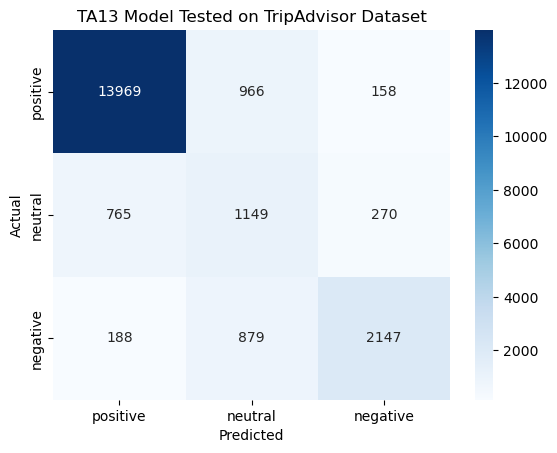

In [33]:
X_trip = trip_df["clean_review"]
y_trip = trip_df["sentiment"]

X_trip_ta13_tfidf = ta13_tfidf.transform(X_trip)
y_pred_ta13_on_trip = ta13_model.predict(X_trip_ta13_tfidf)

print("TA13 model tested on TripAdvisor dataset")
print(classification_report(y_trip, y_pred_ta13_on_trip))

cm = confusion_matrix(
    y_trip,
    y_pred_ta13_on_trip,
    labels=["positive", "neutral", "negative"]
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["positive", "neutral", "negative"],
    yticklabels=["positive", "neutral", "negative"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("TA13 Model Tested on TripAdvisor Dataset")
plt.show()

# TA13 Overall Model and Aspect Model

In [41]:
import os
import re
import joblib

# Aspect columns used in TA13
aspect_cols = [
    "value",
    "service",
    "location",
    "rooms",
    "cleanliness",
    "sleep_quality"
]

# Keywords used only to check whether the aspect is mentioned
aspect_detection_keywords = {
    "value": [
        "price", "value", "expensive", "cheap", "worth", "money",
        "cost", "overpriced", "reasonable", "affordable"
    ],
    "service": [
        "staff", "service", "reception", "receptionist", "front desk",
        "manager", "concierge", "rude", "friendly", "helpful", "unhelpful"
    ],
    "location": [
        "location", "station", "walk", "near", "transport", "city",
        "airport", "beach", "shopping", "subway", "bus", "train"
    ],
    "rooms": [
        "room", "bed", "pillow", "shower", "aircon", "air conditioning",
        "noise", "view", "wifi", "tv", "furniture"
    ],
    "cleanliness": [
        "clean", "dirty", "bathroom", "toilet", "smell", "dust",
        "hygiene", "mold", "stain", "filthy", "spotless"
    ],
    "sleep_quality": [
        "sleep", "quiet", "noisy", "noise", "bed", "pillow",
        "mattress", "comfortable", "uncomfortable"
    ]
}

def clean_review_text(review):
    review_clean = re.sub(r"[^a-zA-Z\s]", " ", str(review).lower())
    review_clean = re.sub(r"\s+", " ", review_clean).strip()
    return review_clean


def detect_mentioned_aspects(review):
    review_lower = str(review).lower()
    mentioned = []

    for aspect, keywords in aspect_detection_keywords.items():
        if any(keyword in review_lower for keyword in keywords):
            mentioned.append(aspect)

    return mentioned


def predict_review_with_overall_and_aspects(review):
    review_clean = clean_review_text(review)

    # -------------------------
    # 1. Overall sentiment model
    # -------------------------
    overall_model = joblib.load("../models/ta13_sentiment_model.pkl")
    overall_tfidf = joblib.load("../models/ta13_tfidf_vectorizer.pkl")

    overall_tfidf_input = overall_tfidf.transform([review_clean])
    overall_prediction = overall_model.predict(overall_tfidf_input)[0]

    overall_confidence = None
    if hasattr(overall_model, "predict_proba"):
        overall_confidence = float(overall_model.predict_proba(overall_tfidf_input).max())

    # -------------------------
    # 2. Aspect sentiment models
    # -------------------------
    mentioned_aspects = detect_mentioned_aspects(review)
    aspect_predictions = {}

    for aspect in aspect_cols:
        if aspect not in mentioned_aspects:
            aspect_predictions[aspect] = {
                "sentiment": "not mentioned",
                "confidence": None
            }
            continue

        model_path = f"../models/aspect_models/{aspect}_sentiment_model.pkl"
        tfidf_path = f"../models/aspect_models/{aspect}_tfidf_vectorizer.pkl"

        if not os.path.exists(model_path) or not os.path.exists(tfidf_path):
            aspect_predictions[aspect] = {
                "sentiment": "model not available",
                "confidence": None
            }
            continue

        aspect_model = joblib.load(model_path)
        aspect_tfidf = joblib.load(tfidf_path)

        aspect_tfidf_input = aspect_tfidf.transform([review_clean])
        aspect_prediction = aspect_model.predict(aspect_tfidf_input)[0]

        aspect_confidence = None
        if hasattr(aspect_model, "predict_proba"):
            aspect_confidence = float(aspect_model.predict_proba(aspect_tfidf_input).max())

        aspect_predictions[aspect] = {
            "sentiment": aspect_prediction,
            "confidence": aspect_confidence
        }

    return {
        "review": review,
        "overall_sentiment": overall_prediction,
        "overall_confidence": overall_confidence,
        "aspects": aspect_predictions
    }

In [ ]:
review = "The bathroom was dirty and the staff were rude, but the location was good and the room was cheap."
review_real = "Everything is top notch. But found it hard to sleep one of the nights due to noise. Walls and floors let a lot of sound through. " \
"One night I could hear neighbor on the left watching a movie, neighbor above walking, people in the corridors walking and talking (despite doing so reasonably), " \
"and people outside the hotel having a casual conversation at normal volume. Guests opening and shutting doors startled me out of sleep a couple of times. " \
"My only complaint though. Staff are awesome and so is the place otherwise."

result = predict_review_with_overall_and_aspects(review_real)

print("Review:", result["review"])
print("Overall:", result["overall_sentiment"], "| Confidence:", round(result["overall_confidence"], 3))

print("\nAspect Sentiment:")
for aspect, info in result["aspects"].items():
    if info["confidence"] is None:
        print(f"{aspect}: {info['sentiment']}")
    else:
        print(f"{aspect}: {info['sentiment']} | Confidence: {round(info['confidence'], 3)}")

Review: Everything is top notch. But found it hard to sleep one of the nights due to noise. Walls and floors let a lot of sound through. One night I could hear neighbor on the left watching a movie, neighbor above walking, people in the corridors walking and talking (despite doing so reasonably), and people outside the hotel having a casual conversation at normal volume. Guests opening and shutting doors startled me out of sleep a couple of times. My only complaint though. Staff are awesome and so is the place otherwise.
Overall: positive | Confidence: 0.553

Aspect Sentiment:
value: not mentioned
service: positive | Confidence: 0.814
location: neutral | Confidence: 0.586
rooms: positive | Confidence: 0.496
cleanliness: not mentioned
sleep_quality: negative | Confidence: 0.945
